# HydroSense-Kenya — Level 4
**ICS 2207 Scientific Computing**

Level 4: Data Cleaning, Scientific Data Analysis, and Visualization

## Overview

In this level we take the raw datasets and go through a proper cleaning process, documenting every decision we make. We then produce scientific visualizations and interpret what they tell us about irrigation needs on the farm.

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import sys
sys.path.insert(0, '..')
from src.data_cleaning import clean_weather, clean_soil
import warnings
warnings.filterwarnings('ignore')
print('imports done')

imports done


## Task 1 — Load Raw Datasets

In [2]:
weather = pd.read_csv('../data/raw/weather_daily.csv', na_values=['NA', ''])
soil    = pd.read_csv('../data/raw/soil_sensor_data.csv', na_values=['NA', ''])
params  = pd.read_csv('../data/raw/crop_zone_parameters.csv', na_values=['NA', ''])

weather['date'] = pd.to_datetime(weather['date'])

print('weather:', weather.shape)
print('soil:   ', soil.shape)
print('params: ', params.shape)

weather: (30, 6)
soil:    (90, 7)
params:  (3, 7)


## Task 2 — Identify Data Quality Issues

Before cleaning anything we first document all the problems we find in the raw data.

In [3]:
print('=== Missing Values ===')
print('weather_daily:')
print(weather.isnull().sum())
print()
print('soil_sensor_data:')
print(soil.isnull().sum())

=== Missing Values ===
weather_daily:
date              0
rainfall_mm       1
temperature_c     0
humidity_pct      1
wind_speed_mps    0
solar_index       0
dtype: int64

soil_sensor_data:
timestamp            0
zone_id              0
soil_moisture_pct    1
tank_level_liters    0
pump_flow_lpm        0
pump_power_watts     0
sensor_status        0
dtype: int64


In [4]:
print('=== Weather Outlier Check ===')
print(weather[['temperature_c', 'rainfall_mm']].describe().round(2))
print()
print('Suspicious temperature values (above 40C):')
print(weather[weather['temperature_c'] > 40][['date', 'temperature_c']])
print()
print('Suspicious rainfall values (above 50mm):')
print(weather[weather['rainfall_mm'] > 50][['date', 'rainfall_mm']])

=== Weather Outlier Check ===
       temperature_c  rainfall_mm
count          30.00        29.00
mean           25.29         8.53
std             4.27        16.37
min            21.40         0.00
25%            23.18         0.70
50%            24.85         3.00
75%            26.52         8.10
max            45.80        85.00

Suspicious temperature values (above 40C):
         date  temperature_c
13 2026-03-14           45.8

Suspicious rainfall values (above 50mm):
         date  rainfall_mm
25 2026-03-26         85.0


In [5]:
print('=== Soil Sensor Anomalies ===')
print('Tank level above 6000L (physical max):')
print(soil[soil['tank_level_liters'] > 6000][['timestamp', 'zone_id', 'tank_level_liters']])
print()
print('Soil moisture below 10% (possible sensor fault):')
print(soil[soil['soil_moisture_pct'] < 10][['timestamp', 'zone_id', 'soil_moisture_pct']])
print()
print('Sensor CHECK status:')
print(soil[soil['sensor_status'] == 'CHECK'][['timestamp', 'zone_id', 'pump_flow_lpm', 'sensor_status']])

=== Soil Sensor Anomalies ===
Tank level above 6000L (physical max):
           timestamp zone_id  tank_level_liters
41  2026-03-14 12:00  Zone_C               9900

Soil moisture below 10% (possible sensor fault):
           timestamp zone_id  soil_moisture_pct
73  2026-03-25 12:00  Zone_B                8.5

Sensor CHECK status:
           timestamp zone_id  pump_flow_lpm sensor_status
61  2026-03-21 12:00  Zone_B            0.0         CHECK


### Summary of Issues Found

| Dataset | Column | Issue | Row/Date |
|---------|--------|-------|----------|
| weather_daily | rainfall_mm | 1 missing value | Mar 8 |
| weather_daily | humidity_pct | 1 missing value | Mar 21 |
| weather_daily | temperature_c | outlier 45.8°C | Mar 14 |
| weather_daily | rainfall_mm | extreme value 85mm | Mar 26 |
| soil_sensor_data | soil_moisture_pct | 1 missing value | Zone_B Mar 6 |
| soil_sensor_data | tank_level_liters | impossible value 9900L | Zone_C Mar 14 |
| soil_sensor_data | pump_flow_lpm | 0.0 with CHECK status | Zone_B Mar 21 |
| soil_sensor_data | soil_moisture_pct | 8.5% below wilting point | Zone_B Mar 25 |

## Task 3 — Clean the Data


In [6]:
weather_clean, weather_log = clean_weather(weather)
soil_clean, soil_log = clean_soil(soil)

print('=== Cleaning Log ===')
for entry in weather_log + soil_log:
    print(' -', entry)

=== Cleaning Log ===
 - rainfall_mm: 1 missing value imputed with median 3.0 mm (Mar 8)
 - humidity_pct: 1 missing value imputed with median 65.1% (Mar 21)
 - temperature_c: outlier 45.8C on Mar 14 capped at 40.0C (not physically realistic for Nairobi in March)
 - soil_moisture_pct: 1 missing value imputed with median 27.5% (Zone_B Mar 6)
 - tank_level_liters: value of 9900L on Zone_C Mar 14 capped at 6000L (exceeds physical tank capacity)
 - soil_moisture_pct: 1 value(s) below 10% replaced with median (likely sensor fault, Zone_B Mar 25)


In [7]:
# save cleaned dataset
weather_clean.to_csv('../data/processed/cleaned_irrigation_dataset.csv', index=False)
print('cleaned dataset saved to data/processed/cleaned_irrigation_dataset.csv')
print('rows:', len(weather_clean))

cleaned dataset saved to data/processed/cleaned_irrigation_dataset.csv
rows: 30


## Task 4 — Descriptive Statistics

We compute summary statistics on the cleaned weather data and soil readings.

In [8]:
print('=== Cleaned Weather Statistics ===')
display(weather_clean.describe().round(2))

print('=== Soil Moisture by Zone ===')
display(soil_clean.groupby('zone_id')['soil_moisture_pct'].describe().round(2))

print('=== Pump Power by Zone ===')
display(soil_clean.groupby('zone_id')['pump_power_watts'].describe().round(2))

=== Cleaned Weather Statistics ===


,date,rainfall_mm,temperature_c,humidity_pct,wind_speed_mps,solar_index
count,30,30.00,30.00,30.00,30.00,30.00
mean,2026-03-15 12:00:00,8.35,25.09,65.67,2.09,0.68
min,2026-03-01 00:00:00,0.00,21.40,56.30,1.14,0.49
25%,2026-03-08 06:00:00,0.75,23.18,63.58,1.66,0.58
50%,2026-03-15 12:00:00,3.00,24.85,65.10,2.12,0.70
75%,2026-03-22 18:00:00,8.00,26.52,68.25,2.40,0.76
max,2026-03-30 00:00:00,85.00,40.00,74.60,3.10,0.80
std,NaN,16.12,3.34,4.02,0.51,0.10


=== Soil Moisture by Zone ===


,count,mean,std,min,25%,50%,75%,max
zone_id,,,,,,,,
Zone_A,30.0,28.62,3.62,22.6,25.68,28.00,31.20,36.1
Zone_B,30.0,29.62,3.50,23.7,27.20,29.95,31.68,36.0
Zone_C,30.0,24.86,3.40,18.6,21.85,25.35,27.60,31.0


=== Pump Power by Zone ===


,count,mean,std,min,25%,50%,75%,max
zone_id,,,,,,,,
Zone_A,30.0,423.40,14.15,394.0,413.50,424.0,434.00,448.0
Zone_B,30.0,461.83,15.06,441.0,452.50,461.0,470.25,500.0
Zone_C,30.0,491.90,13.45,463.0,487.25,492.0,499.75,523.0


## Task 5 — Scientific Visualizations

### Plot 1 — Rainfall and Temperature (Dual Axis)

**Interpretation:** Rainfall events are concentrated in the second half of March, particularly the large event on Mar 26. Temperature stays relatively stable around 23-27°C throughout the month with the exception of the cleaned outlier on Mar 14. The pattern suggests the first two weeks had higher irrigation demand due to low rainfall.

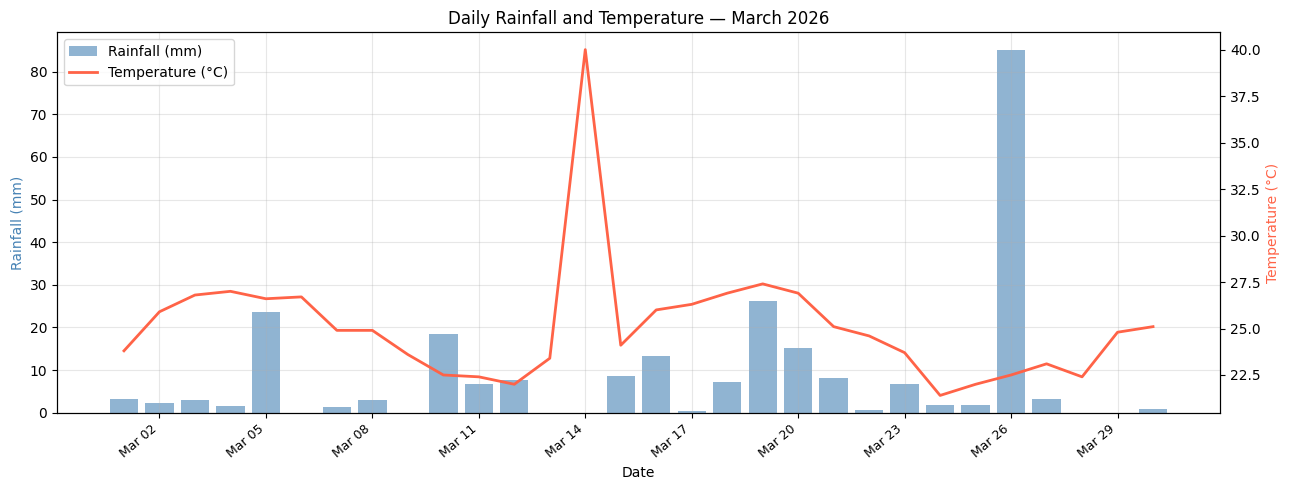

In [9]:
fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

ax1.bar(weather_clean['date'], weather_clean['rainfall_mm'],
        color='steelblue', alpha=0.6, label='Rainfall (mm)')
ax2.plot(weather_clean['date'], weather_clean['temperature_c'],
         color='tomato', linewidth=2, label='Temperature (°C)')

ax1.set_xlabel('Date')
ax1.set_ylabel('Rainfall (mm)', color='steelblue')
ax2.set_ylabel('Temperature (°C)', color='tomato')
ax1.set_title('Daily Rainfall and Temperature — March 2026')

ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.setp(ax1.get_xticklabels(), rotation=40, ha='right', fontsize=9)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/plot1_rainfall_temperature.png', dpi=150)
plt.show()

### Plot 2 — Soil Moisture by Zone Over Time

**Interpretation:** All three zones show a general downward trend in soil moisture over the month, with Zone C dropping the lowest. The dashed horizontal lines mark the minimum moisture threshold for each zone. Zone C spends several days below its threshold toward the end of the month, indicating the maize crop was under water stress. The spike around Mar 26 corresponds to the large rainfall event.

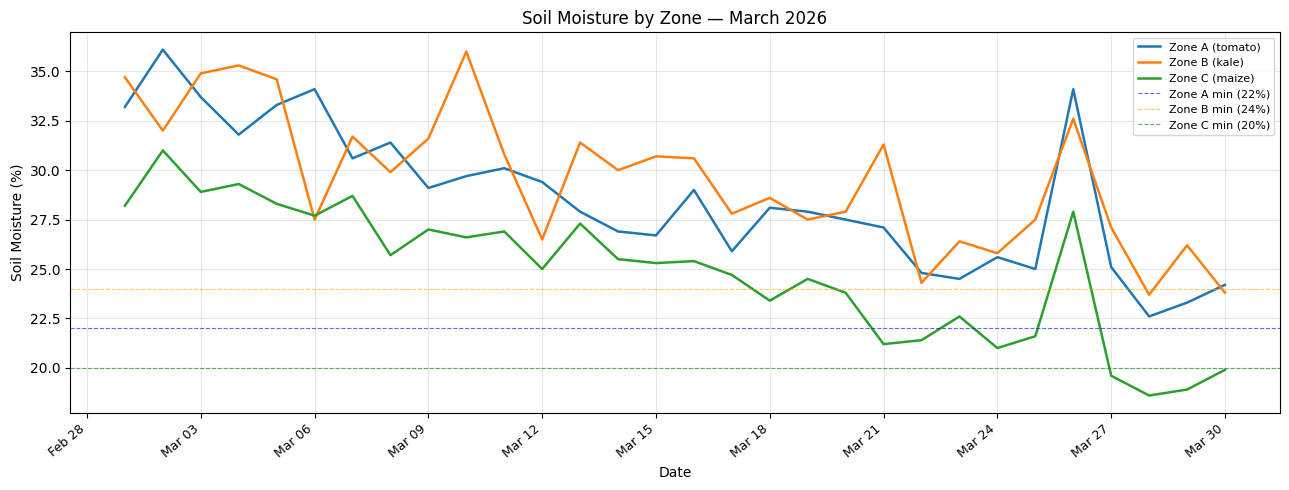

In [10]:
zone_a = soil_clean[soil_clean['zone_id'] == 'Zone_A'].copy()
zone_b = soil_clean[soil_clean['zone_id'] == 'Zone_B'].copy()
zone_c = soil_clean[soil_clean['zone_id'] == 'Zone_C'].copy()

zone_a['date'] = pd.to_datetime(zone_a['timestamp'].str[:10])
zone_b['date'] = pd.to_datetime(zone_b['timestamp'].str[:10])
zone_c['date'] = pd.to_datetime(zone_c['timestamp'].str[:10])

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(zone_a['date'], zone_a['soil_moisture_pct'], label='Zone A (tomato)', linewidth=1.8)
ax.plot(zone_b['date'], zone_b['soil_moisture_pct'], label='Zone B (kale)', linewidth=1.8)
ax.plot(zone_c['date'], zone_c['soil_moisture_pct'], label='Zone C (maize)', linewidth=1.8)

# minimum thresholds from params
ax.axhline(22, color='blue', linestyle='--', linewidth=0.8, alpha=0.6, label='Zone A min (22%)')
ax.axhline(24, color='orange', linestyle='--', linewidth=0.8, alpha=0.6, label='Zone B min (24%)')
ax.axhline(20, color='green', linestyle='--', linewidth=0.8, alpha=0.6, label='Zone C min (20%)')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.setp(ax.get_xticklabels(), rotation=40, ha='right', fontsize=9)

ax.set_title('Soil Moisture by Zone — March 2026')
ax.set_xlabel('Date')
ax.set_ylabel('Soil Moisture (%)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/plot2_soil_moisture_zones.png', dpi=150)
plt.show()

### Plot 3 — ET Distribution

**Interpretation:** ET values range from about 3 to 6 mm/day with most days clustering around 4-5 mm/day. The distribution is roughly symmetric, suggesting ET was fairly consistent throughout the month. The primary drivers of variability are solar index and wind speed since temperature stayed relatively stable.

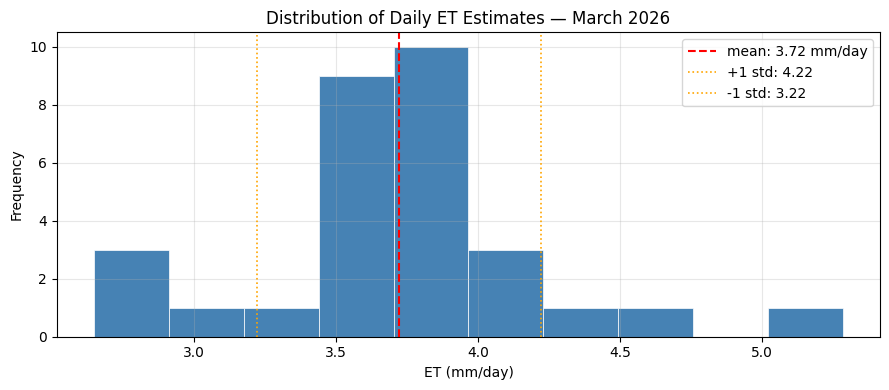

In [11]:
et_values = np.maximum(
    0,
    0.12*weather_clean['temperature_c']
    + 0.35*weather_clean['wind_speed_mps']
    + 2.4*weather_clean['solar_index']
    - 0.025*weather_clean['humidity_pct']
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(et_values, bins=10, color='steelblue', edgecolor='white', linewidth=0.5)
ax.axvline(et_values.mean(), color='red', linestyle='--', linewidth=1.5,
           label='mean: ' + str(round(et_values.mean(), 2)) + ' mm/day')
ax.axvline(et_values.mean() + et_values.std(), color='orange', linestyle=':',
           linewidth=1.2, label='+1 std: ' + str(round(et_values.mean()+et_values.std(), 2)))
ax.axvline(et_values.mean() - et_values.std(), color='orange', linestyle=':',
           linewidth=1.2, label='-1 std: ' + str(round(et_values.mean()-et_values.std(), 2)))
ax.set_title('Distribution of Daily ET Estimates — March 2026')
ax.set_xlabel('ET (mm/day)')
ax.set_ylabel('Frequency')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/plot3_et_distribution.png', dpi=150)
plt.show()

### Plot 4 — Correlation Matrix

**Interpretation:** Temperature and solar index show a moderate positive correlation with ET, which makes physical sense since both drive evaporation. Humidity shows a negative correlation with ET as expected — higher humidity reduces the atmosphere's capacity to absorb water vapor. Rainfall has little correlation with the other weather variables, confirming it is driven by different atmospheric processes.

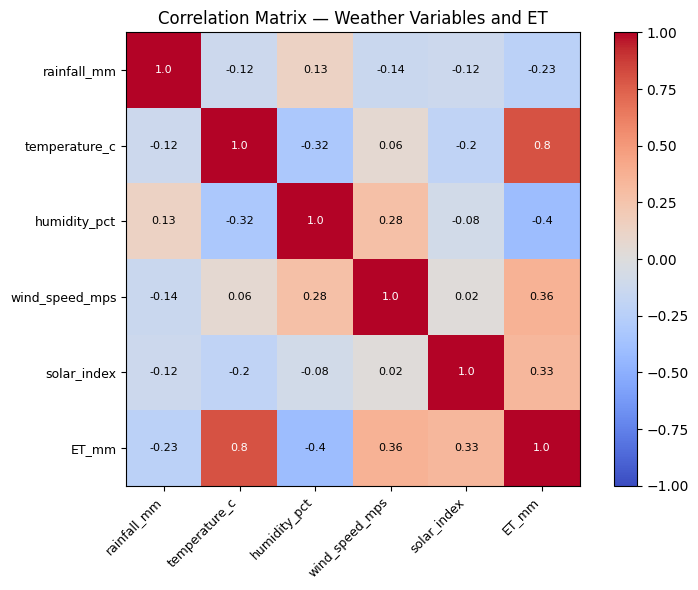

In [12]:
weather_clean['ET_mm'] = et_values
corr_cols = ['rainfall_mm', 'temperature_c', 'humidity_pct', 'wind_speed_mps', 'solar_index', 'ET_mm']
corr = weather_clean[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(corr_cols, fontsize=9)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, str(corr.values[i, j]),
                ha='center', va='center', fontsize=8,
                color='white' if abs(corr.values[i, j]) > 0.5 else 'black')

ax.set_title('Correlation Matrix — Weather Variables and ET')
plt.tight_layout()
plt.savefig('../reports/plot4_correlation_matrix.png', dpi=150)
plt.show()

### Plot 5 — Tank Level Depletion by Zone

**Interpretation:** All three zones show a steady decline in tank water level over the month as irrigation continues. Zone C depletes fastest due to its larger area (180 m²) and higher pump flow rates. The anomalous spike in Zone C on Mar 14 (9900L) was cleaned before plotting. The declining trend across all zones signals that by end of March the farm would need a water resupply.

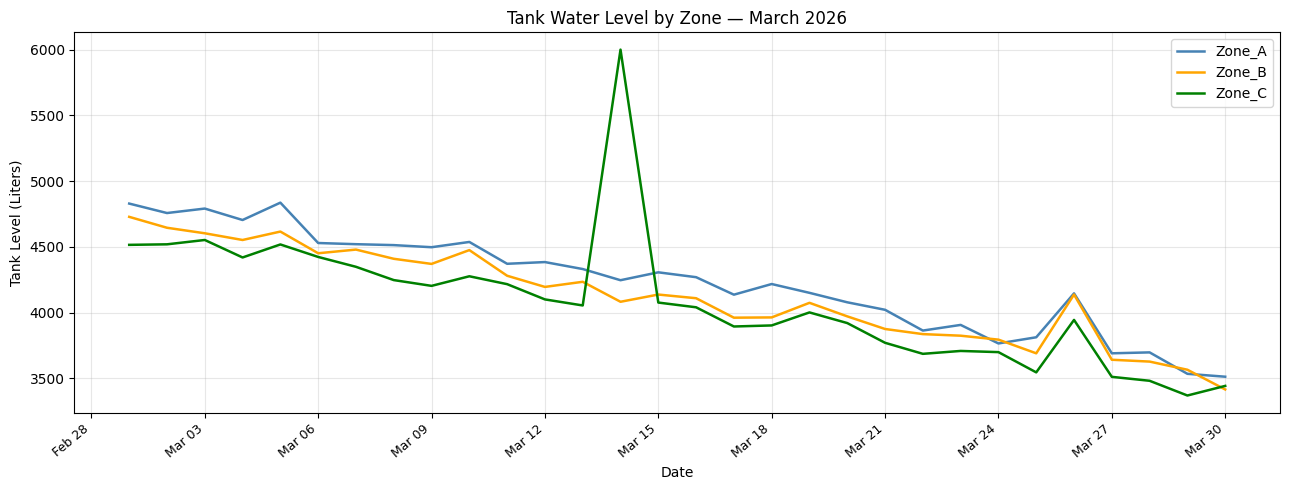

In [13]:
fig, ax = plt.subplots(figsize=(13, 5))

for zone, color in zip(['Zone_A', 'Zone_B', 'Zone_C'], ['steelblue', 'orange', 'green']):
    z = soil_clean[soil_clean['zone_id'] == zone].copy()
    z['date'] = pd.to_datetime(z['timestamp'].str[:10])
    ax.plot(z['date'], z['tank_level_liters'], label=zone, color=color, linewidth=1.8)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.setp(ax.get_xticklabels(), rotation=40, ha='right', fontsize=9)

ax.set_title('Tank Water Level by Zone — March 2026')
ax.set_xlabel('Date')
ax.set_ylabel('Tank Level (Liters)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/plot5_tank_levels.png', dpi=150)
plt.show()